# Phase 3: Storage + Hydropower Matching — Moore Dam (1981)

**Goal:** Extend Phase 1 by adding hydropower objectives alongside storage matching.

**Weighted loss function:**
```
  L = lam_storage * (mse_storage / ref_storage)
    + lam_shape   * (mse_shape   / ref_shape)
    + lam_annual  * (mse_annual  / ref_annual)
    + lam_smooth  * smoothness_reg
```

This notebook compares a storage-only **base case** with several **weighted cases**
to examine whether hydropower matching can be improved and to visualize the
trade-off between storage fidelity and energy production.


In [11]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax.numpy as jnp

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "LM_26").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PACKAGE_DIR = PROJECT_ROOT / "LM_26"
INPUT_DIR = PACKAGE_DIR / "input_data_Moore"
OUTPUT_DIR = PACKAGE_DIR / "outputs_Moore"
FIGURE_DIR = OUTPUT_DIR / "figures"
PARAM_DIR = OUTPUT_DIR / "best_params_hydro"

# Keep these folders available if you later decide to save outputs.
for directory in [OUTPUT_DIR, FIGURE_DIR, PARAM_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


from LM_26 import load_dam_data
from hydro_optimizer import run_multistart, summarize_cases

## 1. Dam Configuration

In [22]:
# File paths
STORAGE_FILE = INPUT_DIR / "MooreDam_1981_tutorial_run_new.csv"
OBS_GEN_FILE = INPUT_DIR / "Moore_dam_monthly_generation.csv"

# Physical parameters
DAM_NAME = "MooreDam"
H_m = 45.72 # design head (m)
P_cap = 47.7 * 4 # installed capacity (MW)
eta = 0.8 # turbine efficiency

# Weighted cases
CASES = {
    "Base": {"lam_storage": 1.0, "lam_hydro_shape": 0.0, "lam_hydro_annual": 0.0},
    "Balanced": {"lam_storage": 0.4, "lam_hydro_shape": 0.3, "lam_hydro_annual": 0.3},
    "Hydro+": {"lam_storage": 0.2, "lam_hydro_shape": 0.4, "lam_hydro_annual": 0.4},
}

# Optimization settings
OPT_SETTINGS = dict(
    num_runs=20,
    learning_rate=1e-2,
    num_iterations=20000,
    lam_smooth=0.02,
    verbose=False
)

## 2. Load Storage Data

In [23]:
data, storage_obs, inflow, biweek_of_year, Smax = load_dam_data(STORAGE_FILE)
sigma_S = float(jnp.std(storage_obs))
print(f"sigma_S = {sigma_S:.2f} MCM")

Loaded 365 days from: /Users/liyingma/MEng_Project/LM_26/input_data_Moore/MooreDam_1981_tutorial_run_new.csv
S0 = 243.50 MCM
Smax = 276.00 MCM  (proxy from observed max)
Mean inflow = 7.04 MCM/day
sigma_S = 28.32 MCM


## 3. Load Hydropower Targets

In [24]:
# Month index aligned to simulation timeline (length T-1, matching run_scan output)
month_id_jax = jnp.array(
    (data["time"].iloc[:-1].dt.month.values - 1).astype(int)
)

# Long-term average monthly generation from observations
obs_df = pd.read_csv(OBS_GEN_FILE)
obs_df["month"] = pd.to_datetime(obs_df["period"], format="%Y-%m")
obs_df["moy"]   = obs_df["month"].dt.month

obs_clim = (
    obs_df.groupby("moy", as_index=False)["gross-generation"]
    .mean()
    .sort_values("moy")
)

obs_monthly_mwh  = obs_clim["gross-generation"].values.astype(float)
annual_obs_mwh   = float(obs_monthly_mwh.sum())
obs_frac_12      = obs_monthly_mwh / annual_obs_mwh
obs_frac_12_jax  = jnp.array(obs_frac_12)

print("Observed monthly fractions (Jan-Dec):")
print(np.round(obs_frac_12, 4))
print(f"Annual target: {annual_obs_mwh/1000:.3f} GWh")

Observed monthly fractions (Jan-Dec):
[0.0822 0.0619 0.0871 0.1594 0.13   0.0798 0.0683 0.0529 0.0379 0.0692
 0.079  0.0922]
Annual target: 287.603 GWh


## 4. Weighted Cases

In [25]:
case_summaries = {}
case_results = {}

for case_name, cfg in CASES.items():
    lam_s = cfg["lam_storage"]
    lam_shape = cfg["lam_hydro_shape"]
    lam_annual = cfg["lam_hydro_annual"]

    print(f"\n{'='*65}")
    print(f"{DAM_NAME} | {case_name} | λs={lam_s}  λm={lam_shape}  λa={lam_annual}")
    print(f"{'='*65}")

    best_params, all_runs, summary = run_multistart(
        inflow_data = inflow,
        storage_obs_data = storage_obs,
        biweek_data = biweek_of_year,
        Smax = Smax,
        month_id_jax = month_id_jax,
        obs_frac_12_jax = obs_frac_12_jax,
        annual_obs_mwh = annual_obs_mwh,
        sigma_S = sigma_S,
        H_m = H_m,
        P_cap = P_cap,
        eta = eta,
        lam_storage = lam_s,
        lam_hydro_shape = lam_shape,
        lam_hydro_annual = lam_annual,
        **OPT_SETTINGS
    )

    case_summaries[case_name] = summary
    case_results[case_name] = {
        "best_params": best_params,
        "all_runs": all_runs,
        "summary": summary,
    }

    # tag = case_name.replace("+", "plus").replace(" ", "_")
    # save_path = PARAM_DIR / f"{DAM_NAME}_{tag}_best_params.npy"
    #np.save(save_path, np.array(best_params))
    #print(f"Saved: {save_path}")



MooreDam | Base | λs=1.0  λm=0.0  λa=0.0

--- Seed 1/20 (seed=0) ---
Total Loss: 0.0007 | Storage RMSE: 0.723 MCM | Annual Bias: -9.22% | Shape Loss: 0.0777

--- Seed 2/20 (seed=1) ---
Total Loss: 0.0007 | Storage RMSE: 0.723 MCM | Annual Bias: -9.22% | Shape Loss: 0.0777

--- Seed 3/20 (seed=2) ---
Total Loss: 0.0007 | Storage RMSE: 0.723 MCM | Annual Bias: -9.22% | Shape Loss: 0.0777

--- Seed 4/20 (seed=3) ---
Total Loss: 0.0007 | Storage RMSE: 0.724 MCM | Annual Bias: -9.22% | Shape Loss: 0.0777

--- Seed 5/20 (seed=4) ---
Total Loss: 0.0007 | Storage RMSE: 0.723 MCM | Annual Bias: -9.22% | Shape Loss: 0.0778

--- Seed 6/20 (seed=5) ---
Total Loss: 0.0007 | Storage RMSE: 0.723 MCM | Annual Bias: -9.22% | Shape Loss: 0.0777

--- Seed 7/20 (seed=6) ---
Total Loss: 0.0007 | Storage RMSE: 0.723 MCM | Annual Bias: -9.22% | Shape Loss: 0.0777

--- Seed 8/20 (seed=7) ---
Total Loss: 0.0007 | Storage RMSE: 0.723 MCM | Annual Bias: -9.22% | Shape Loss: 0.0777

--- Seed 9/20 (seed=8) ---
To

In [19]:
# Plot helper

def print_case_table(case_rows):
    df = pd.DataFrame(case_rows)
    show_cols = [
        "case",
        "lam_storage", "lam_hydro_shape", "lam_hydro_annual",
        "storage_rmse", "hydro_shape_loss", "hydro_annual_loss",
        "annual_sim_gwh", "bias_percent", "total_loss",
        "weighted_storage_term", "weighted_shape_term", "weighted_annual_term",
    ]
    show_cols = [c for c in show_cols if c in df.columns]
    print(df[show_cols].to_string(index=False))
    return df


def plot_tradeoff(case_rows,
                  x_key="storage_rmse",
                  y_key="bias_percent",
                  title=None,
                  annotate=True):
    plt.figure(figsize=(6, 4))
    for row in case_rows:
        plt.scatter(row[x_key], row[y_key], s=70, label=row["case"])
        if annotate:
            plt.annotate(row["case"], (row[x_key], row[y_key]),
                         textcoords="offset points", xytext=(6, 4), fontsize=9)
    plt.xlabel(x_key.replace("_", " ").title())
    plt.ylabel(y_key.replace("_", " ").title())
    plt.title(title or f"{DAM_NAME} — Trade-off")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_case_storage_and_hydro(case_name, summary, data_time, storage_obs, obs_frac_12):
    m = summary["best_metrics"]
    months = np.arange(1, 13)
    month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # Storage
    axes[0].plot(data_time, np.array(storage_obs),
                 linewidth=2, label="Observed")
    axes[0].plot(data_time.values[1:], m["S_sim"],
                linestyle="--", linewidth=2, label="Simulated")
    axes[0].set_ylabel("Storage (MCM)")
    axes[0].set_title(f"{DAM_NAME} — {case_name} | RMSE={m['storage_rmse']:.2f} MCM")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Monthly hydro fractions
    axes[1].bar(months - 0.2, obs_frac_12, width=0.4, label="Observed")
    axes[1].bar(months + 0.2, m["sim_frac_12"], width=0.4, label="Simulated")
    axes[1].set_xticks(months)
    axes[1].set_xticklabels(month_names)
    axes[1].set_ylabel("Fraction of Annual Energy")
    axes[1].set_title(
        f"Annual sim={m['annual_sim_gwh']:.2f} GWh  |  Bias={m['bias_percent']:+.1f}%"
    )
    axes[1].legend()
    axes[1].grid(alpha=0.3, axis="y")

    plt.suptitle(
        f"{case_name}  (λs={m['lam_storage']}, λm={m['lam_hydro_shape']}, λa={m['lam_hydro_annual']})",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()


## 5. Diagnostic Plots — Per Case

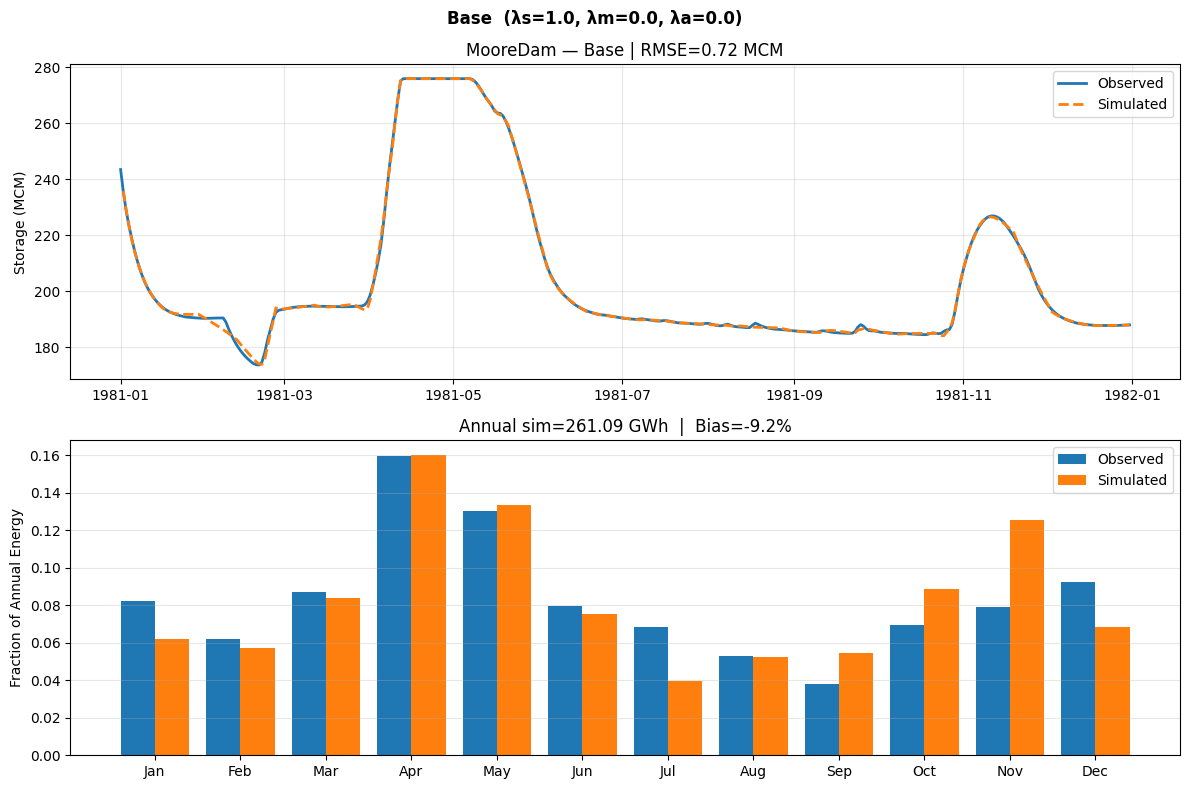

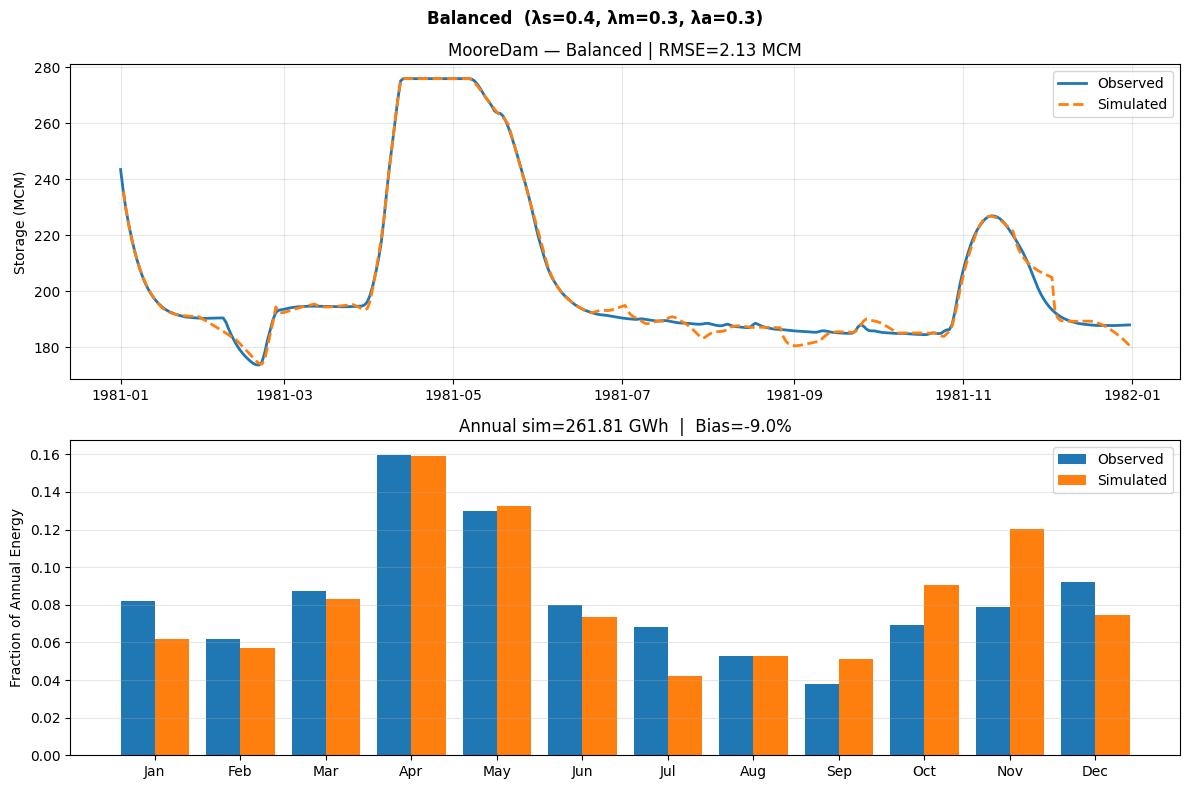

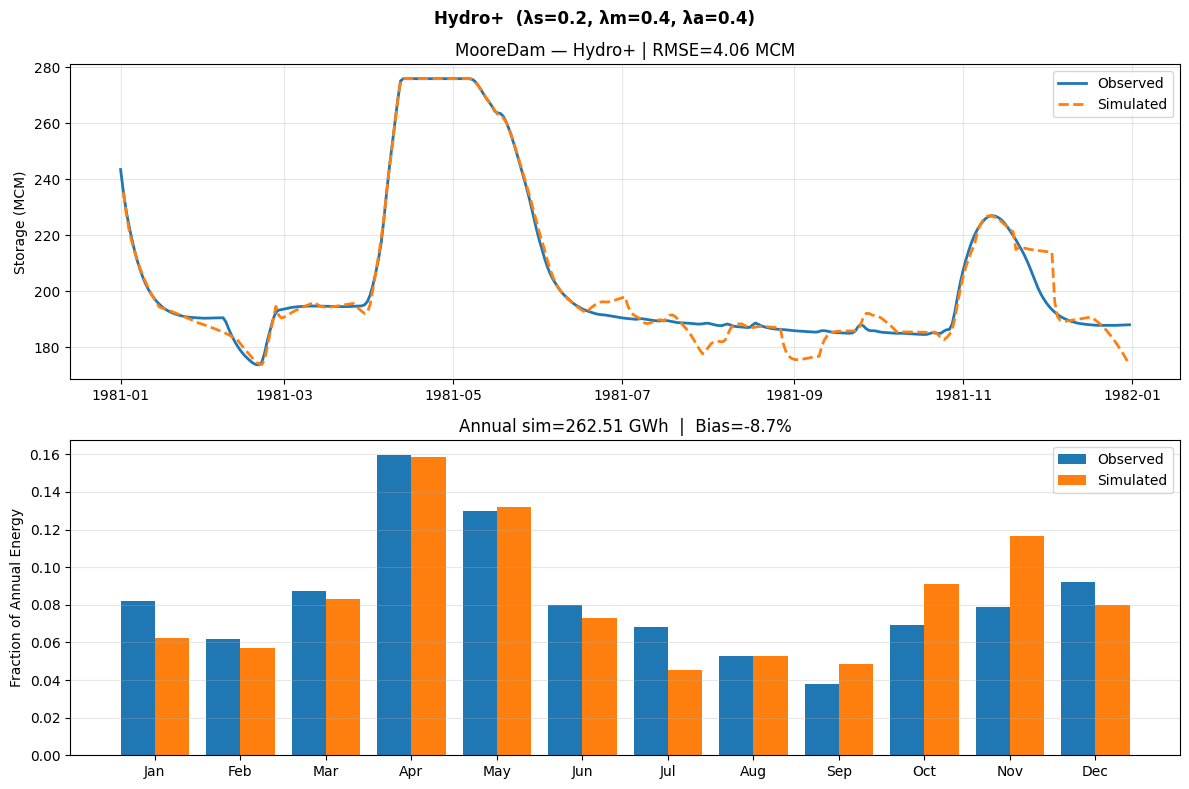

In [26]:
for case_name, summary in case_summaries.items():
    plot_case_storage_and_hydro(
        case_name=case_name,
        summary=summary,
        data_time=data["time"],
        storage_obs=storage_obs,
        obs_frac_12=obs_frac_12
    )


## 6. Trade-off Plots

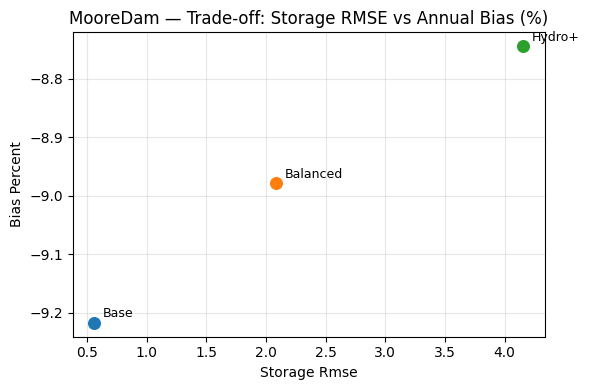

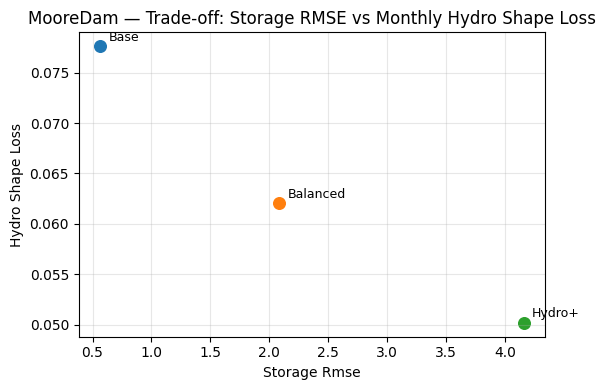

In [21]:
case_rows = summarize_cases(case_summaries)
plot_tradeoff(
    case_rows,
    x_key="storage_rmse",
    y_key="bias_percent",
    title=f"{DAM_NAME} — Trade-off: Storage RMSE vs Annual Bias (%)"
)

plot_tradeoff(
    case_rows,
    x_key="storage_rmse",
    y_key="hydro_shape_loss",
    title=f"{DAM_NAME} — Trade-off: Storage RMSE vs Monthly Hydro Shape Loss"
)
